# DataCo Supply Chain — Exploratory Data Analysis

**Dataset**: DataCo Smart Supply Chain (Kaggle)  
**Purpose**: Profile the raw data ahead of two downstream tasks:
- **Phase 1/3** — Capacitated Facility Location (CFLP) optimizer needs facility coordinates, demand nodes, and demand volumes
- **Phase 2** — Binary delay classifier predicting `Late_delivery_risk`

---
**Sections**
1. Basic Overview
2. Data Quality Assessment
3. Column Classification
4. Target Variable
5. Leakage Audit
6. Numeric Feature Distributions
7. Categorical Feature Distributions
8. Feature-Target Relationships
9. Correlation Analysis
10. Temporal Analysis
11. Geographic Analysis (CFLP Inputs)
12. Summary & Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import chi2_contingency, pointbiserialr
from IPython.display import display
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'figure.dpi': 100,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_theme(style='whitegrid', palette='muted')

RAW_DATA = Path('../data/raw/DataCoSupplyChainDataset.csv')
print('Libraries loaded.')

Libraries loaded.


In [2]:
# latin-1 required — file contains Spanish/accented characters
df = pd.read_csv(RAW_DATA, encoding='latin-1')
df.columns = df.columns.str.strip()  # some column names have trailing whitespace
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class


---
## 1. Basic Overview

In [3]:
dtype_counts = df.dtypes.value_counts().rename_axis('dtype').reset_index(name='count')
print('Data type distribution:')
print(dtype_counts.to_string(index=False))
print()
print('Full column -> dtype mapping:')
print(df.dtypes.to_string())

Data type distribution:
  dtype  count
    str     24
float64     15
  int64     14

Full column -> dtype mapping:
Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name         

In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.50,1.62,0.00,2.00,3.00,5.00,6.00
Days for shipment (scheduled),180519.0,2.93,1.37,0.00,2.00,4.00,4.00,4.00
Benefit per order,180519.0,21.97,104.43,-4274.98,7.00,31.52,64.80,911.80
Sales per customer,180519.0,183.11,120.04,7.49,104.38,163.99,247.40,1939.99
Late_delivery_risk,180519.0,0.55,0.50,0.00,0.00,1.00,1.00,1.00
Category Id,180519.0,31.85,15.64,2.00,18.00,29.00,45.00,76.00
Customer Id,180519.0,6691.38,4162.92,1.00,3258.50,6457.00,9779.00,20757.00
Customer Zipcode,180516.0,35921.13,37542.46,603.00,725.00,19380.00,78207.00,99205.00
Department Id,180519.0,5.44,1.63,2.00,4.00,5.00,7.00,12.00
Latitude,180519.0,29.72,9.81,-33.94,18.27,33.14,39.28,48.78


In [5]:
df.describe(include='object').T

,count,unique,top,freq
Type,180519,4,DEBIT,69295
Delivery Status,180519,4,Late delivery,98977
Category Name,180519,50,Cleats,24551
Customer City,180519,563,Caguas,66770
Customer Country,180519,2,EE. UU.,111146
Customer Email,180519,1,XXXXXXXXX,180519
Customer Fname,180519,782,Mary,65150
Customer Lname,180511,1109,Smith,64104
Customer Password,180519,1,XXXXXXXXX,180519
Customer Segment,180519,3,Consumer,93504


---
## 2. Data Quality Assessment

### 2.1 Missing Values

Columns with missing values: 4 of 53


,missing_count,missing_pct
Product Description,180519,100.00
Order Zipcode,155679,86.24
Customer Lname,8,0.00
Customer Zipcode,3,0.00


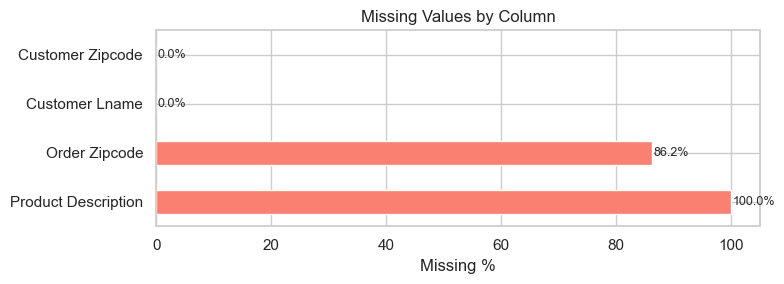

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = (
    pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
    .query('missing_count > 0')
    .sort_values('missing_count', ascending=False)
)
print(f'Columns with missing values: {len(missing_df)} of {df.shape[1]}')
display(missing_df)

if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_df) * 0.6)))
    missing_df['missing_pct'].plot.barh(ax=ax, color='salmon', edgecolor='white')
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    for i, v in enumerate(missing_df['missing_pct']):
        ax.text(v + 0.2, i, f'{v:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

### 2.2 Effectively Empty Columns

In [7]:
empty_cols = []
for col in df.columns:
    pct_null = df[col].isna().mean()
    if pct_null == 1.0:
        empty_cols.append((col, '100% null'))
    elif df[col].dtype == object:
        pct_blank = (df[col].fillna('').str.strip() == '').mean()
        if pct_blank > 0.95:
            empty_cols.append((col, f'{pct_blank:.1%} blank or null'))

print('Effectively empty columns (>95% blank/null):')
if empty_cols:
    for col, reason in empty_cols:
        print(f'  {col}: {reason}')
else:
    print('  None found.')

Effectively empty columns (>95% blank/null):
  Product Description: 100% null


### 2.3 Duplicate Rows & Order Structure

In [8]:
n_full_dupes = df.duplicated().sum()
print(f'Fully duplicate rows    : {n_full_dupes:,}')
print()
print(f'Unique Order IDs        : {df["Order Id"].nunique():,}')
print(f'Total rows              : {len(df):,}')
print(f'Avg line items / order  : {len(df) / df["Order Id"].nunique():.2f}')
print()
# Customer Id vs Order Customer Id — should be identical
always_match = (df['Customer Id'] == df['Order Customer Id']).all()
print(f'Customer Id == Order Customer Id (always): {always_match}')
print('  -> One of these is redundant and can be dropped.')

Fully duplicate rows    : 0

Unique Order IDs        : 65,752
Total rows              : 180,519
Avg line items / order  : 2.75

Customer Id == Order Customer Id (always): True
  -> One of these is redundant and can be dropped.


### 2.4 Zero / Near-Zero Variance Columns

In [9]:
print('Columns with <= 2 unique values:')
found = False
for col in df.columns:
    n_unique = df[col].nunique(dropna=False)
    if n_unique <= 2:
        print(f'  {col}: {n_unique} unique -> {df[col].unique()[:5]}')
        found = True
if not found:
    print('  None with <=2 unique values.')

Columns with <= 2 unique values:
  Late_delivery_risk: 2 unique -> [0 1]
  Customer Country: 2 unique -> <ArrowStringArray>
['Puerto Rico', 'EE. UU.']
Length: 2, dtype: str
  Customer Email: 1 unique -> <ArrowStringArray>
['XXXXXXXXX']
Length: 1, dtype: str
  Customer Password: 1 unique -> <ArrowStringArray>
['XXXXXXXXX']
Length: 1, dtype: str
  Product Description: 1 unique -> [nan]
  Product Status: 1 unique -> [0]


### 2.5 PII & Masked Columns

In [10]:
pii_cols = ['Customer Email', 'Customer Fname', 'Customer Lname', 'Customer Password']
print('PII columns (all should be XXXXXXXXX):')
for col in pii_cols:
    unique_vals = df[col].unique()[:5]
    print(f'  {col}: {unique_vals}')
print()
print('All masked -> zero signal, safe to drop.')

PII columns (all should be XXXXXXXXX):
  Customer Email: <ArrowStringArray>
['XXXXXXXXX']
Length: 1, dtype: str
  Customer Fname: <ArrowStringArray>
['Cally', 'Irene', 'Gillian', 'Tana', 'Orli']
Length: 5, dtype: str
  Customer Lname: <ArrowStringArray>
['Holloway', 'Luna', 'Maldonado', 'Tate', 'Hendricks']
Length: 5, dtype: str
  Customer Password: <ArrowStringArray>
['XXXXXXXXX']
Length: 1, dtype: str

All masked -> zero signal, safe to drop.


### 2.6 Floating-Point Precision Noise

In [ ]:
col = 'Order Item Discount Rate'
sample = df[col].dropna().head(10).values
print(f'{col} (first 10 values):')
print(sample)
print()
max_deviation = (df[col] - df[col].round(2)).abs().max()
print(f'Max deviation from 2-decimal rounding: {max_deviation:.2e}')
print('-> Safe to round to 2 decimal places in preprocessing.')

### 2.7 Redundant ID Columns

In [ ]:
id_cols = ['Product Card Id', 'Order Item Cardprod Id', 'Product Category Id', 'Category Id', 'Department Id']
print('Cardinality of ID-like columns:')
for col in id_cols:
    print(f'  {col}: {df[col].nunique():,} unique values')
print()
pct_match = (df['Product Card Id'] == df['Order Item Cardprod Id']).mean()
print(f'Product Card Id == Order Item Cardprod Id: {pct_match:.1%} of rows')
pct_match2 = (df['Category Id'] == df['Product Category Id']).mean()
print(f'Category Id == Product Category Id       : {pct_match2:.1%} of rows')

---
## 3. Column Classification

Every column tagged as: **TARGET**, **LEAKAGE**, **KEEP-ML**, **KEEP-CFLP**, or **DROP**.

In [ ]:
classification = [
    # (column, tag, reason)
    ('Late_delivery_risk',            'TARGET',    'Binary classification target'),
    # --- LEAKAGE ---
    ('Delivery Status',               'LEAKAGE',   'Perfect text encoding of target; encodes Late/OnTime/Advance/Canceled'),
    ('Days for shipping (real)',       'LEAKAGE',   'Actual shipping days - only known post-delivery'),
    ('shipping date (DateOrders)',     'LEAKAGE',   'Actual ship date - post-fulfillment'),
    ('Order Status',                  'LEAKAGE',   'COMPLETE/CANCELED/etc. - status finalized after fulfillment'),
    ('Benefit per order',             'LEAKAGE',   'Profit derived after fulfillment'),
    ('Order Profit Per Order',        'LEAKAGE',   'Post-fulfillment profit'),
    ('Order Item Profit Ratio',       'LEAKAGE',   'Post-fulfillment profit ratio'),
    ('Sales per customer',            'LEAKAGE',   'Aggregate across orders - cross-order leakage'),
    # --- KEEP ML ---
    ('Shipping Mode',                 'KEEP-ML',   'Strong predictor; encodes expected transit speed'),
    ('Days for shipment (scheduled)', 'KEEP-ML',   'Scheduled delivery window; tighter deadline -> higher delay risk'),
    ('Type',                          'KEEP-ML',   'Payment type (DEBIT/CASH/TRANSFER/PAYMENT)'),
    ('Market',                        'KEEP-ML',   'High-level geographic market'),
    ('Order Region',                  'KEEP-ML',   'Regional geography - 22+ regions'),
    ('Order Country',                 'KEEP-ML',   'Destination country'),
    ('Customer Segment',              'KEEP-ML',   'Consumer/Corporate/Home Office - order behavior proxy'),
    ('Category Name',                 'KEEP-ML',   'Product category; affects handling complexity'),
    ('Department Name',               'KEEP-ML',   'Department grouping'),
    ('Order Item Quantity',           'KEEP-ML+CFLP', 'Demand volume; also d_j in CFLP'),
    ('Order Item Total',              'KEEP-ML+CFLP', 'Monetary demand; also useful in CFLP'),
    ('Product Price',                 'KEEP-ML',   'Product value; high-value items may get priority handling'),
    ('Order Item Discount Rate',      'KEEP-ML',   'Discount level; proxy for promotion/product type'),
    ('order date (DateOrders)',       'KEEP-ML',   'Extract month/quarter for seasonality features'),
    # --- KEEP CFLP ---
    ('Latitude',                      'KEEP-CFLP', 'Facility/store latitude -> candidate facility nodes'),
    ('Longitude',                     'KEEP-CFLP', 'Facility/store longitude -> candidate facility nodes'),
    ('Order City',                    'KEEP-CFLP', 'Demand node city'),
    ('Order State',                   'KEEP-CFLP', 'Demand node state'),
    # --- DROP ---
    ('Customer Email',                'DROP',      'PII; all XXXXXXXXX'),
    ('Customer Fname',                'DROP',      'PII; all XXXXXXXXX'),
    ('Customer Lname',                'DROP',      'PII; all XXXXXXXXX'),
    ('Customer Password',             'DROP',      'PII; all XXXXXXXXX'),
    ('Customer Id',                   'DROP',      'ID only; identical to Order Customer Id'),
    ('Order Customer Id',             'DROP',      'ID only; duplicate of Customer Id'),
    ('Order Id',                      'DROP',      'ID only'),
    ('Order Item Id',                 'DROP',      'ID only'),
    ('Order Item Cardprod Id',        'DROP',      'Same values as Product Card Id'),
    ('Category Id',                   'DROP',      'Redundant; Category Name captures this'),
    ('Department Id',                 'DROP',      'Redundant; Department Name captures this'),
    ('Product Card Id',               'DROP',      'ID only'),
    ('Product Category Id',           'DROP',      'Redundant; same as Category Id'),
    ('Product Description',           'DROP',      'Effectively empty column'),
    ('Product Image',                 'DROP',      'URLs only; no predictive value'),
    ('Order Zipcode',                 'DROP',      '>95% missing'),
    ('Product Status',                'DROP',      'Near-constant (almost all 0 = in-stock)'),
    ('Customer City',                 'DROP',      'Store registration city, NOT delivery destination'),
    ('Customer Country',              'DROP',      'Store country (uses Spanish abbrev "EE. UU." for USA)'),
    ('Customer State',                'DROP',      'Store registration state'),
    ('Customer Street',               'DROP',      'Store street address'),
    ('Customer Zipcode',              'DROP',      'Store zipcode'),
    ('Product Name',                  'DROP',      'High cardinality; Category/Department already cover this'),
    ('Order Item Product Price',      'DROP',      'Duplicate of Product Price'),
    ('Order Item Discount',           'DROP',      'Dollar amount; rate is more interpretable'),
    ('Sales',                         'DROP',      'Alias for Order Item Total'),
]

icons = {'TARGET': '[TARGET]', 'LEAKAGE': '[LEAKAGE]', 'KEEP-ML': '[KEEP-ML]',
         'KEEP-ML+CFLP': '[KEEP-ML+CFLP]', 'KEEP-CFLP': '[KEEP-CFLP]', 'DROP': '[DROP]'}

print(f'{"Column":<35} {"Tag":<16} Reason')
print('-' * 100)
for col, tag, reason in classification:
    print(f'{col:<35} {icons[tag]:<16} {reason}')

tag_counts = pd.Series([t for _, t, _ in classification]).value_counts()
print()
print('Tag summary:')
print(tag_counts.to_string())

---
## 4. Target Variable: `Late_delivery_risk`

In [ ]:
target_counts = df['Late_delivery_risk'].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(1)

print('Class distribution:')
print(pd.DataFrame({'count': target_counts, 'pct_%': target_pct}).to_string())
print()
imbalance_ratio = target_counts.max() / target_counts.min()
print(f'Imbalance ratio (majority:minority): {imbalance_ratio:.2f}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(
    ['On Time (0)', 'Late (1)'],
    target_counts.values,
    color=['steelblue', 'salmon'],
    edgecolor='white'
)
for i, (cnt, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    axes[0].text(i, cnt + 500, f'{cnt:,}\n({pct:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Late_delivery_risk Class Balance')
axes[0].set_ylabel('Count')

axes[1].pie(
    target_counts.values,
    labels=['On Time (0)', 'Late (1)'],
    colors=['steelblue', 'salmon'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

---
## 5. Leakage Audit

Three columns contain post-fulfillment information that perfectly or near-perfectly predicts the target.  
**None of these can appear as ML training features.**

### 5.1 `Delivery Status` — Direct text encoding of the target

In [ ]:
ct = pd.crosstab(df['Delivery Status'], df['Late_delivery_risk'])
print('Delivery Status vs Late_delivery_risk (crosstab):')
display(ct)
print()
print('Mapping:')
for status in df['Delivery Status'].unique():
    vals = df[df['Delivery Status'] == status]['Late_delivery_risk'].unique()
    print(f'  "{status}" -> Late_delivery_risk = {vals}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt=',', cmap='Oranges', ax=ax, linewidths=0.5)
ax.set_title('Delivery Status x Late_delivery_risk\n(off-diagonal zeros confirm perfect mapping = leakage)')
plt.tight_layout()
plt.show()

### 5.2 `Days for shipping (real)` — Post-fulfillment timing

The difference `real_days - scheduled_days` is strongly correlated with the target  
but is **not** a perfect predictor because canceled orders (Late_delivery_risk=0)  
can still have `real_days > scheduled_days`.  
Either way, this column is only observable *after* delivery completes.

In [ ]:
df['days_diff'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

check = (
    df.groupby(['Delivery Status', df['days_diff'] > 0])['Late_delivery_risk']
    .mean()
    .unstack()
    .round(3)
)
check.columns = ['days_diff <= 0', 'days_diff > 0']
print('Mean of Late_delivery_risk by (Delivery Status, days_diff > 0):')
display(check)
print()
print('Finding: days_diff > 0 is necessary but NOT sufficient.')
print('Canceled orders can overshoot the schedule yet still have Late_delivery_risk=0.')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, val, color in [(axes[0], 0, 'steelblue'), (axes[1], 1, 'salmon')]:
    subset = df[df['Late_delivery_risk'] == val]['Days for shipping (real)']
    ax.hist(subset, bins=10, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f'Days for shipping (real)\n[Late_delivery_risk = {val}]')
    ax.set_xlabel('Actual Shipping Days')
    ax.set_ylabel('Count')
plt.suptitle('Post-hoc feature: only observable after delivery completes', style='italic', fontsize=10)
plt.tight_layout()
plt.show()

# Clean up temp column
df.drop(columns=['days_diff'], inplace=True)

---
## 6. Numeric Feature Distributions

Only features available at order-placement time (no leakage columns).

In [ ]:
num_features = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Product Price',
    'Order Item Total',
]

fig, axes = plt.subplots(1, len(num_features), figsize=(20, 4))
for ax, col in zip(axes, num_features):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Count')
    median = df[col].median()
    ax.axvline(median, color='crimson', linestyle='--', linewidth=1, label=f'median={median:.1f}')
    ax.legend(fontsize=7)
plt.suptitle('Numeric Feature Distributions (order-time features only)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
outlier_report = []
for col in num_features:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report.append({
        'column': col, 'q1': round(q1, 2), 'q3': round(q3, 2), 'iqr': round(iqr, 2),
        'lower_fence': round(lower, 2), 'upper_fence': round(upper, 2),
        'n_outliers': n_out, 'pct_outliers': round(n_out / len(df) * 100, 2)
    })

display(pd.DataFrame(outlier_report).set_index('column'))

fig, axes = plt.subplots(1, len(num_features), figsize=(20, 4))
for ax, col in zip(axes, num_features):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='crimson', linewidth=2))
    ax.set_title(col, fontsize=9)
plt.suptitle('Box Plots — Outlier Visualization (IQR method)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 7. Categorical Feature Distributions

In [ ]:
cat_features = ['Shipping Mode', 'Market', 'Customer Segment', 'Type', 'Category Name', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_features):
    vc = df[col].value_counts()
    ax.barh(vc.index, vc.values, color='steelblue', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Count')
    for i, v in enumerate(vc.values):
        ax.text(v + 200, i, f'{v:,}', va='center', fontsize=8)
plt.suptitle('Categorical Feature Distributions', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
region_vc = df['Order Region'].value_counts()
fig, ax = plt.subplots(figsize=(10, 8))
region_vc.plot.barh(ax=ax, color='cornflowerblue', edgecolor='white')
ax.set_title('Order Region — Value Counts')
ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

---
## 8. Feature-Target Relationships

For each feature, compute the delay rate (mean of `Late_delivery_risk`) per category.

### 8.1 Shipping Mode

In [ ]:
mode_stats = (
    df.groupby('Shipping Mode')['Late_delivery_risk']
    .agg(delay_rate='mean', n='count')
    .sort_values('delay_rate', ascending=False)
)
mode_stats['delay_rate_pct'] = (mode_stats['delay_rate'] * 100).round(1)
display(mode_stats)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['salmon' if r > 0.5 else 'steelblue' for r in mode_stats['delay_rate']]
ax.barh(mode_stats.index, mode_stats['delay_rate_pct'], color=colors, edgecolor='white')
ax.axvline(50, color='black', linestyle='--', alpha=0.5, label='50%')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Late Delivery Rate by Shipping Mode')
ax.legend()
for i, v in enumerate(mode_stats['delay_rate_pct']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 8.2 Days for Shipment (Scheduled)

In [ ]:
sched_stats = (
    df.groupby('Days for shipment (scheduled)')['Late_delivery_risk']
    .agg(delay_rate='mean', n='count')
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(
    sched_stats['Days for shipment (scheduled)'],
    sched_stats['delay_rate'] * 100,
    color='steelblue', edgecolor='white'
)
axes[0].set_xlabel('Days for Shipment (Scheduled)')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].set_title('Delay Rate by Scheduled Days')

for val, label, color in [(0, 'On Time', 'steelblue'), (1, 'Late', 'salmon')]:
    subset = df[df['Late_delivery_risk'] == val]['Days for shipment (scheduled)']
    axes[1].hist(subset, bins=range(1, 10), alpha=0.6, label=label, color=color, density=True)
axes[1].set_xlabel('Days for Shipment (Scheduled)')
axes[1].set_ylabel('Density')
axes[1].set_title('Scheduled Days Distribution by Target')
axes[1].legend()

plt.tight_layout()
plt.show()

### 8.3 Market & Order Region

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

mkt_stats = (
    df.groupby('Market')['Late_delivery_risk']
    .mean().sort_values(ascending=True) * 100
)
mkt_stats.plot.barh(ax=axes[0], color='cornflowerblue', edgecolor='white')
axes[0].axvline(50, linestyle='--', color='black', alpha=0.4)
axes[0].set_xlabel('Delay Rate (%)')
axes[0].set_title('Delay Rate by Market')
for i, v in enumerate(mkt_stats.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

region_stats = (
    df.groupby('Order Region')['Late_delivery_risk']
    .agg(delay_rate='mean', n='count')
    .query('n > 500')
    .sort_values('delay_rate')['delay_rate'] * 100
)
region_stats.plot.barh(ax=axes[1], color='cornflowerblue', edgecolor='white')
axes[1].axvline(50, linestyle='--', color='black', alpha=0.4)
axes[1].set_xlabel('Delay Rate (%)')
axes[1].set_title('Delay Rate by Order Region (n > 500)')

plt.tight_layout()
plt.show()

### 8.4 Customer Segment & Payment Type

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, ['Customer Segment', 'Type']):
    stats = (
        df.groupby(col)['Late_delivery_risk']
        .mean().sort_values(ascending=True) * 100
    )
    colors = ['salmon' if v > 50 else 'steelblue' for v in stats.values]
    stats.plot.barh(ax=ax, color=colors, edgecolor='white')
    ax.axvline(50, linestyle='--', color='black', alpha=0.4)
    ax.set_xlabel('Delay Rate (%)')
    ax.set_title(f'Delay Rate by {col}')
    for i, v in enumerate(stats.values):
        ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 8.5 Category Name

In [ ]:
cat_stats = (
    df.groupby('Category Name')['Late_delivery_risk']
    .agg(delay_rate='mean', n='count')
    .query('n > 100')
    .sort_values('delay_rate')
)
cat_stats['delay_rate_pct'] = (cat_stats['delay_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, max(4, len(cat_stats) * 0.45)))
colors = ['salmon' if v > 50 else 'steelblue' for v in cat_stats['delay_rate']]
ax.barh(cat_stats.index, cat_stats['delay_rate_pct'], color=colors, edgecolor='white')
ax.axvline(50, linestyle='--', color='black', alpha=0.4, label='50%')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Delay Rate by Category Name (n > 100)')
ax.legend()
plt.tight_layout()
plt.show()

### 8.6 Department Name

In [ ]:
dept_stats = (
    df.groupby('Department Name')['Late_delivery_risk']
    .agg(delay_rate='mean', n='count')
    .sort_values('delay_rate')
)
dept_stats['delay_rate_pct'] = (dept_stats['delay_rate'] * 100).round(1)

fig, ax = plt.subplots(figsize=(10, max(4, len(dept_stats) * 0.45)))
colors = ['salmon' if v > 50 else 'steelblue' for v in dept_stats['delay_rate']]
ax.barh(dept_stats.index, dept_stats['delay_rate_pct'], color=colors, edgecolor='white')
ax.axvline(50, linestyle='--', color='black', alpha=0.4, label='50%')
ax.set_xlabel('Delay Rate (%)')
ax.set_title('Delay Rate by Department Name')
ax.legend()
for i, v in enumerate(dept_stats['delay_rate_pct']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 8.7 Remaining Numeric Features vs Target

`Days for shipment (scheduled)` was already shown in 8.2. The four remaining numeric KEEP-ML features are shown here split by target class. Heavily overlapping boxes confirm the weak point-biserial correlations in Section 9.2.

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, ['Product Price', 'Order Item Total', 'Order Item Discount Rate', 'Order Item Quantity']):
    groups = [
        df[df['Late_delivery_risk'] == 0][col].dropna(),
        df[df['Late_delivery_risk'] == 1][col].dropna(),
    ]
    bp = ax.boxplot(groups, patch_artist=True, labels=['On Time (0)', 'Late (1)'])
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('salmon')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax.set_title(col, fontsize=9)
    ax.set_ylabel('Value')
plt.suptitle('Numeric Features by Delay Status — overlapping distributions confirm weak discriminative signal', fontsize=10)
plt.tight_layout()
plt.show()

### 8.8 Shipping Mode × Scheduled Days — Interaction Effect

The two strongest legitimate predictors crossed against each other. A uniform gradient (no diagonal hotspot) would mean the effects are purely additive — any deviation reveals an interaction that may be worth engineering as a feature.

In [ ]:
pivot = (
    df.groupby(['Shipping Mode', 'Days for shipment (scheduled)'])['Late_delivery_risk']
    .mean()
    .unstack('Days for shipment (scheduled)')
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    pivot * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
    vmin=0, vmax=100, linewidths=0.5, ax=ax, cbar_kws={'label': 'Delay Rate (%)'}
)
ax.set_title('Delay Rate (%) — Shipping Mode × Scheduled Days
(reveals whether signals interact or combine additively)')
ax.set_xlabel('Days for Shipment (Scheduled)')
ax.set_ylabel('Shipping Mode')
plt.tight_layout()
plt.show()

---
## 9. Correlation Analysis

### 9.1 Cramér's V — Categorical Features vs Target

Cramér's V measures association strength between two categorical variables. Range [0, 1].  
Interpretation: < 0.1 = negligible, 0.1-0.3 = weak, 0.3-0.6 = moderate, > 0.6 = strong.

In [ ]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    ct = pd.crosstab(x, y)
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    # Bergsma (2013) bias correction — clamp avoids negative values on small contingency tables
    phi2_corr = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)  # corrected row count
    k_corr = k - (k - 1) ** 2 / (n - 1)  # corrected col count
    denom = min(r_corr - 1, k_corr - 1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else 0.0


all_cat = [
    'Shipping Mode', 'Market', 'Customer Segment', 'Type',
    'Category Name', 'Department Name', 'Order Region', 'Order Country',
    'Order Status', 'Delivery Status',  # included to confirm leakage
]
target_str = df['Late_delivery_risk'].astype(str)

scores = {col: cramers_v(df[col].fillna('MISSING'), target_str) for col in all_cat}
cv_df = pd.Series(scores).sort_values(ascending=True).to_frame("Cramer's V")

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = [
    'crimson' if v > 0.6 else ('darkorange' if v > 0.3 else 'steelblue')
    for v in cv_df["Cramer's V"]
]
cv_df["Cramer's V"].plot.barh(ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(0.1, color='gray', linestyle=':', label='Weak (0.1)')
ax.axvline(0.3, color='orange', linestyle='--', label='Moderate (0.3)')
ax.axvline(0.6, color='crimson', linestyle='--', label='Strong (0.6)')
ax.set_title("Cramer's V — Categorical Feature Association with Late_delivery_risk")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print()
print('Note: Delivery Status and Order Status will show near-perfect V -> confirmed leakage.')
print('For non-leakage features, Shipping Mode is likely the strongest signal.')

### 9.2 Point-Biserial Correlation — Numeric Features vs Target

In [ ]:
num_for_corr = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Product Price',
    'Order Item Total',
    'Days for shipping (real)',  # included to confirm magnitude of leakage
]

corr_rows = []
for col in num_for_corr:
    valid = df[[col, 'Late_delivery_risk']].dropna()
    r, p = pointbiserialr(valid[col], valid['Late_delivery_risk'])
    corr_rows.append({
        'feature': col,
        'r': round(r, 4),
        'p_value': round(p, 4),
        'is_leakage': col == 'Days for shipping (real)'
    })

corr_df = pd.DataFrame(corr_rows).set_index('feature').sort_values('r')
display(corr_df)

fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ['crimson' if leak else ('salmon' if r > 0 else 'steelblue')
              for r, leak in zip(corr_df['r'], corr_df['is_leakage'])]
ax.barh(corr_df.index, corr_df['r'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Point-Biserial r')
ax.set_title('Numeric Feature Correlation with Late_delivery_risk\n(crimson = leakage column)')
plt.tight_layout()
plt.show()

### 9.3 Numeric-Numeric Correlation (Multicollinearity Check)

In [ ]:
num_cols_clean = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Product Price',
    'Order Item Total',
]
corr_matrix = df[num_cols_clean].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, linewidths=0.5, ax=ax, vmin=-1, vmax=1
)
ax.set_title('Numeric Feature Correlation Matrix')
plt.tight_layout()
plt.show()

### 9.4 Mutual Information — Unified Feature Ranking

Cramér's V (categorical) and point-biserial r (numeric) can't be directly compared across types. Mutual Information scores all features on the same scale and captures non-linear associations — important because XGBoost/LightGBM will exploit non-linearities that correlation metrics miss.

In [ ]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

ml_features_list = [
    'Shipping Mode', 'Days for shipment (scheduled)', 'Market', 'Order Region',
    'Order Country', 'Customer Segment', 'Category Name', 'Department Name',
    'Type', 'Order Item Quantity', 'Order Item Total', 'Product Price',
    'Order Item Discount Rate',
]

X_mi = df[ml_features_list].copy()
for col in X_mi.select_dtypes('object').columns:
    le = LabelEncoder()
    # LabelEncoder raises on NaN; inject a sentinel string category instead
    X_mi[col] = le.fit_transform(X_mi[col].fillna('MISSING').astype(str))
X_mi = X_mi.fillna(X_mi.median(numeric_only=True))

mi_scores = mutual_info_classif(X_mi, df['Late_delivery_risk'], random_state=42)
mi_series = pd.Series(mi_scores, index=ml_features_list).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['salmon' if v >= mi_series.median() else 'steelblue' for v in mi_series]
mi_series.plot.barh(ax=ax, color=bar_colors, edgecolor='white')
ax.axvline(mi_series.median(), linestyle='--', color='black', alpha=0.5, label='Median MI')
ax.set_xlabel('Mutual Information Score')
ax.set_title("Mutual Information vs Late_delivery_risk\n(unified ranking — captures non-linear associations)")
ax.legend(fontsize=9)
for i, v in enumerate(mi_series):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

print()
print("Compare top features here with Cramer's V (9.1) and point-biserial r (9.2) for consistency.")
print('MI is scale-invariant and works across both categorical and numeric types.')

---
## 10. Temporal Analysis

In [ ]:
df['order_date'] = pd.to_datetime(df['order date (DateOrders)'], format='%m/%d/%Y %H:%M')
df['year_month'] = df['order_date'].dt.to_period('M')

print(f'Date range: {df["order_date"].min().date()} to {df["order_date"].max().date()}')
print(f'Span      : {(df["order_date"].max() - df["order_date"].min()).days} days')

monthly = (
    df.groupby('year_month')
    .agg(n_rows=('Order Id', 'count'), delay_rate=('Late_delivery_risk', 'mean'))
    .reset_index()
)
monthly['ym_str'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(monthly['ym_str'], monthly['n_rows'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
axes[0].set_ylabel('Order Line Items')
axes[0].set_title('Monthly Order Volume')

axes[1].plot(monthly['ym_str'], monthly['delay_rate'] * 100, color='salmon', linewidth=1.5, marker='o', markersize=3)
axes[1].axhline(df['Late_delivery_risk'].mean() * 100, linestyle='--', color='black', alpha=0.4, label='Overall mean')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_title('Monthly Delay Rate')
axes[1].legend()

# ~12 evenly-spaced ticks; max(1, …) prevents ZeroDivisionError on short date ranges
tick_indices = list(range(0, len(monthly), max(1, len(monthly) // 12)))
axes[1].set_xticks(tick_indices)
axes[1].set_xticklabels(
    [monthly['ym_str'].iloc[i] for i in tick_indices],
    rotation=45, ha='right'
)
plt.tight_layout()
plt.show()

---
## 11. Geographic Analysis — CFLP Inputs

- `Latitude` / `Longitude` = **store/facility coordinates** -> candidate facility nodes for CFLP
- `Order City` / `Order Country` = **demand nodes** (delivery destinations)

In [ ]:
facility_locs = df[['Latitude', 'Longitude']].drop_duplicates().dropna()
print(f'Unique facility coordinates : {len(facility_locs):,}')
print(f'Latitude range  : {facility_locs["Latitude"].min():.2f} to {facility_locs["Latitude"].max():.2f}')
print(f'Longitude range : {facility_locs["Longitude"].min():.2f} to {facility_locs["Longitude"].max():.2f}')
print()
print('Note: For Phase 1 CFLP, unique (Lat, Lon) pairs define candidate facility nodes.')
print('You will likely need to cluster/aggregate these to a tractable number (e.g. k=10-50).')

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(
    facility_locs['Longitude'], facility_locs['Latitude'],
    alpha=0.3, s=10, c='steelblue', edgecolors='none'
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'Candidate Facility Locations ({len(facility_locs):,} unique coordinates)')
plt.tight_layout()
plt.show()

In [ ]:
demand_summary = (
    df.groupby('Order Country')
    .agg(
        order_items=('Order Id', 'count'),
        total_demand_usd=('Order Item Total', 'sum'),
        delay_rate=('Late_delivery_risk', 'mean')
    )
    .sort_values('order_items', ascending=False)
    .head(20)
)
demand_summary['avg_order_value'] = (
    demand_summary['total_demand_usd'] / demand_summary['order_items']
).round(2)
demand_summary['delay_rate'] = (demand_summary['delay_rate'] * 100).round(1)
demand_summary['total_demand_usd'] = demand_summary['total_demand_usd'].round(0)

print('Top 20 Order Countries (demand nodes):')
display(demand_summary)

print()
print(f'Unique order countries : {df["Order Country"].nunique():,}')
print(f'Unique order cities    : {df["Order City"].nunique():,}')
print()
print('Note for CFLP: demand nodes need lat/lon coordinates.')
print('Either geocode Order City/Country or aggregate by Order Region (22 groups).')

---
## 12. Summary & Recommendations

### Data Quality Issues to Fix in Preprocessing

| Issue | Fix |
|---|---|
| File encoding | Load with `encoding='latin-1'` |
| Column name whitespace | `df.columns.str.strip()` |
| `Order Zipcode` >95% missing | Drop |
| `Product Description` effectively empty | Drop |
| `Order Item Discount Rate` float noise | Round to 2 d.p. |
| `Customer Country` Spanish abbreviations ("EE. UU.") | Normalize to English or encode as-is |
| `Order Customer Id` == `Customer Id` | Drop one |
| Date columns stored as object | Parse with `pd.to_datetime` |

### Confirmed Leakage Columns — Exclude from ML
- `Delivery Status` — perfect text encoding of the target
- `Days for shipping (real)` — actual shipping days, only known post-delivery
- `shipping date (DateOrders)` — actual ship date
- `Order Status` — fulfillment status (COMPLETE/CANCELED/etc.)
- `Benefit per order`, `Order Profit Per Order`, `Order Item Profit Ratio` — post-fulfillment derived

### Recommended ML Feature Set (Phase 2 Input)

| Feature | Type | Notes |
|---|---|---|
| `Shipping Mode` | categorical | Strongest legitimate predictor |
| `Days for shipment (scheduled)` | numeric | Deadline tightness |
| `Market` | categorical | High-level geography |
| `Order Region` | categorical | Fine-grained geography |
| `Order Country` | categorical | High cardinality — consider grouping |
| `Customer Segment` | categorical | Order behavior proxy |
| `Category Name` | categorical | Product handling complexity |
| `Department Name` | categorical | Correlated with Category |
| `Type` | categorical | Payment method |
| `Order Item Quantity` | numeric | Volume; also CFLP demand input |
| `Order Item Total` | numeric | Value; also CFLP demand input |
| `Product Price` | numeric | Item value |
| `Order Item Discount Rate` | numeric | Promotion/product proxy |
| `order_month` | numeric | Derived from order date |
| `order_quarter` | numeric | Derived from order date |

### CFLP Inputs (Phases 1 & 3)
- **Facility nodes**: unique `(Latitude, Longitude)` pairs — will need clustering to reduce to tractable k
- **Demand nodes**: `Order City` / `Order Country` — need geocoding, or use `Order Region` (22 groups) to reduce size
- **Demand volume** `d_j`: aggregate `Order Item Total` (or `Order Item Quantity`) per demand node
- **Route cost** `c_ij`: haversine distance between facility and demand node coordinates

In [ ]:
ml_features = {
    'Shipping Mode'                 : 'categorical',
    'Days for shipment (scheduled)' : 'numeric',
    'Market'                        : 'categorical',
    'Order Region'                  : 'categorical',
    'Order Country'                 : 'categorical',
    'Customer Segment'              : 'categorical',
    'Category Name'                 : 'categorical',
    'Department Name'               : 'categorical',
    'Type'                          : 'categorical',
    'Order Item Quantity'           : 'numeric',
    'Order Item Total'              : 'numeric',
    'Product Price'                 : 'numeric',
    'Order Item Discount Rate'      : 'numeric',
    'order_month'                   : 'numeric (derived)',
    'order_quarter'                 : 'numeric (derived)',
}

print(f'{"Feature":<35} {"Type"}')
print('-' * 60)
for feat, ftype in ml_features.items():
    print(f'{feat:<35} {ftype}')
print()
print(f'Total features : {len(ml_features)}')
print(f'Target         : Late_delivery_risk (binary)')